# RetailPulse - Day 9

## Churn Prediction using XGBoost with SHAP Explainability

Objective:
Build a classification model to identify at-risk (churned) customers using RFM and behavioral features, balance classes with SMOTE, and explain predictions with SHAP.

Targets: AUC-ROC >= 0.88, Precision@Top20% >= 0.75

In [2]:
!pip install xgboost

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)


In [4]:
!pip install shap

  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)

   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]



In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    classification_report,
    confusion_matrix
)

from imblearn.over_sampling import SMOTE

import xgboost as xgb

import shap

## Step 1: Load RFM and Cleaned Data

In [6]:
rfm = pd.read_csv("../data/rfm_segmented.csv")

cleaned = pd.read_csv("../data/cleaned_retail.csv")

print(rfm.shape)

rfm.head()

(4338, 6)


,Customer ID,Recency,Frequency,Monetary,Cluster,Segment
0,12346.0,326,1,77183.60,1,VIP
1,12347.0,2,182,4310.00,0,Regular
2,12348.0,75,31,1797.24,0,Regular
3,12349.0,19,73,1757.55,0,Regular
4,12350.0,310,17,334.40,1,VIP


In [7]:
rfm.columns

Index(['Customer ID', 'Recency', 'Frequency', 'Monetary', 'Cluster',
       'Segment'],
      dtype='object')

## Step 2: Explore Recency Distribution

We look at the distribution of Recency (days since last purchase) to decide a sensible churn threshold.

In [8]:
rfm["Recency"].describe()

count    4338.000000
mean       92.536422
std       100.014169
min         1.000000
25%        18.000000
50%        51.000000
75%       142.000000
max       374.000000
Name: Recency, dtype: float64

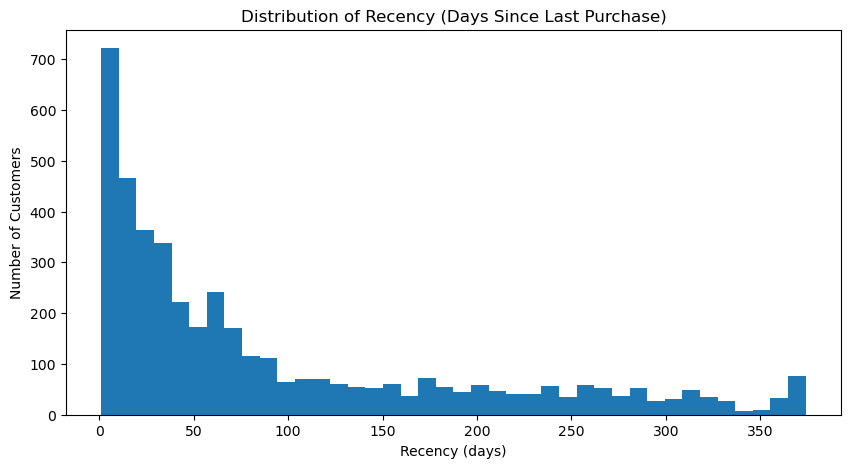

In [9]:
plt.figure(figsize=(10,5))

plt.hist(rfm["Recency"], bins=40)

plt.title("Distribution of Recency (Days Since Last Purchase)")

plt.xlabel("Recency (days)")
plt.ylabel("Number of Customers")

plt.show()

In [10]:
for q in [0.5, 0.6, 0.7, 0.75, 0.8, 0.9]:
    print(f"{int(q*100)}th percentile Recency:", rfm["Recency"].quantile(q))

50th percentile Recency: 51.0
60th percentile Recency: 72.0
70th percentile Recency: 108.0
75th percentile Recency: 142.0
80th percentile Recency: 179.0
90th percentile Recency: 263.0


## Step 3: Define Churn Label

Based on the distribution above, we set a Recency threshold (in days). Customers with Recency greater than this threshold are labeled as churned (1), others as active (0).

**Adjust `CHURN_THRESHOLD` below after reviewing the histogram and percentiles** - a good starting point is around the 75th percentile of Recency.

In [11]:
CHURN_THRESHOLD = int(rfm["Recency"].quantile(0.75))

print("Churn threshold (days):", CHURN_THRESHOLD)

rfm["Churn"] = (rfm["Recency"] > CHURN_THRESHOLD).astype(int)

rfm["Churn"].value_counts(normalize=True)

Churn threshold (days): 142


Churn
0    0.750115
1    0.249885
Name: proportion, dtype: float64

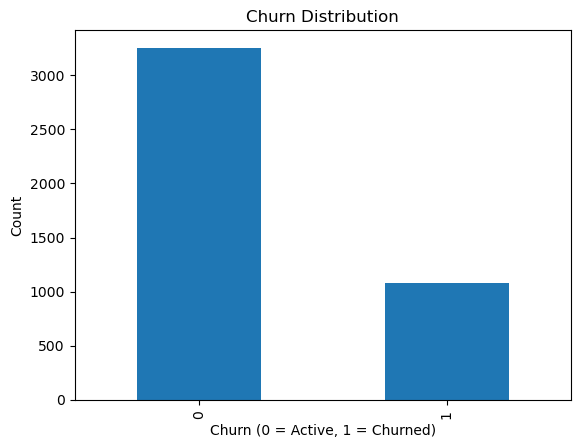

In [12]:
rfm["Churn"].value_counts().plot(kind="bar")

plt.title("Churn Distribution")

plt.xlabel("Churn (0 = Active, 1 = Churned)")
plt.ylabel("Count")

plt.show()

## Step 4: Build Additional Behavioral Features

We compute extra customer-level behavioral features from the cleaned transaction data (CustomerFrequency, OrderSize, average order value, unique products purchased) and merge them with the RFM table.

In [13]:
cleaned.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country', 'TotalAmount', 'Year', 'Month',
       'Day', 'Weekday', 'Quarter', 'CustomerFrequency', 'OrderSize'],
      dtype='object')

In [14]:
behavior = cleaned.groupby("Customer ID").agg(
    AvgOrderValue=("TotalAmount", "mean"),
    UniqueProducts=("StockCode", "nunique"),
    TotalQuantity=("Quantity", "sum"),
    AvgCustomerFrequency=("CustomerFrequency", "mean")
)

behavior.head()

,AvgOrderValue,UniqueProducts,TotalQuantity,AvgCustomerFrequency
Customer ID,,,,
12346.0,77183.600000,1,74215,1.0
12347.0,23.681319,103,2458,182.0
12348.0,57.975484,22,2341,31.0
12349.0,24.076027,73,631,73.0
12350.0,19.670588,17,197,17.0


In [15]:
rfm = rfm.merge(behavior, on="Customer ID", how="left")

print(rfm.shape)

rfm.head()

(4338, 11)


,Customer ID,Recency,Frequency,Monetary,Cluster,Segment,Churn,AvgOrderValue,UniqueProducts,TotalQuantity,AvgCustomerFrequency
0,12346.0,326,1,77183.60,1,VIP,1,77183.600000,1,74215,1.0
1,12347.0,2,182,4310.00,0,Regular,0,23.681319,103,2458,182.0
2,12348.0,75,31,1797.24,0,Regular,0,57.975484,22,2341,31.0
3,12349.0,19,73,1757.55,0,Regular,0,24.076027,73,631,73.0
4,12350.0,310,17,334.40,1,VIP,1,19.670588,17,197,17.0


## Step 5: Prepare Features and Target

In [16]:
feature_cols = [
    "Recency",
    "Frequency",
    "Monetary",
    "AvgOrderValue",
    "UniqueProducts",
    "TotalQuantity",
    "AvgCustomerFrequency"
]

X = rfm[feature_cols]
y = rfm["Churn"]

print(X.shape)
print(y.value_counts())

(4338, 7)
Churn
0    3254
1    1084
Name: count, dtype: int64


In [17]:
X.isnull().sum()

Recency                 0
Frequency               0
Monetary                0
AvgOrderValue           0
UniqueProducts          0
TotalQuantity           0
AvgCustomerFrequency    0
dtype: int64

In [18]:
X = X.fillna(0)

## Step 6: Train-Test Split

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(3470, 7)
(868, 7)


## Step 7: Handle Class Imbalance with SMOTE

SMOTE is applied only to the training data to avoid data leakage into the test set.

In [20]:
print("Before SMOTE:")
print(y_train.value_counts())

smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print(y_train_res.value_counts())

Before SMOTE:
Churn
0    2603
1     867
Name: count, dtype: int64

After SMOTE:
Churn
0    2603
1    2603
Name: count, dtype: int64


## Step 8: Train XGBoost Classifier

In [21]:
model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="auc",
    random_state=42
)

model.fit(X_train_res, y_train_res)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'auc'


## Step 9: Evaluate Model

In [22]:
y_pred = model.predict(X_test)

y_proba = model.predict_proba(X_test)[:,1]

auc = roc_auc_score(y_test, y_proba)

print("AUC-ROC:", auc)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

AUC-ROC: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       651
           1       1.00      1.00      1.00       217

    accuracy                           1.00       868
   macro avg       1.00      1.00      1.00       868
weighted avg       1.00      1.00      1.00       868



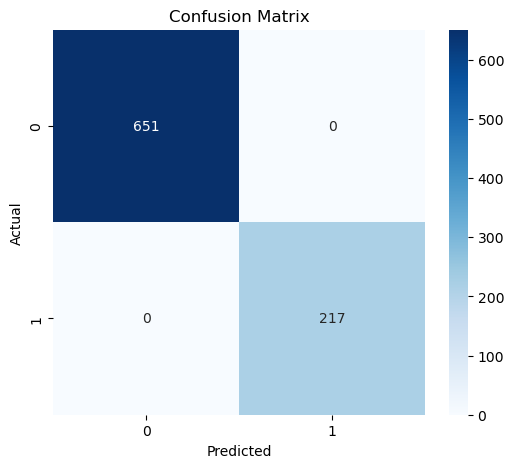

In [24]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

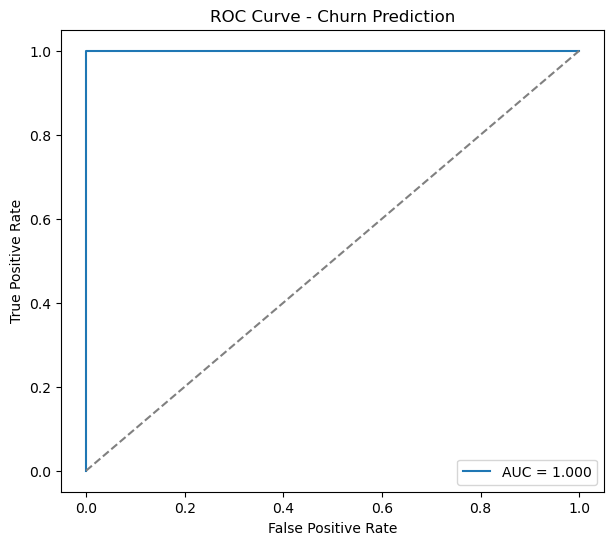

In [25]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(7,6))

plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")

plt.plot([0,1],[0,1], linestyle="--", color="gray")

plt.title("ROC Curve - Churn Prediction")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()

plt.show()

## Step 10: Precision @ Top 20%

We sort customers by predicted churn probability and check what fraction of the top 20% riskiest customers are truly churned. Target: >= 0.75

In [26]:
eval_df = pd.DataFrame({
    "actual": y_test.values,
    "proba": y_proba
})

eval_df = eval_df.sort_values("proba", ascending=False).reset_index(drop=True)

top_20_pct = int(len(eval_df) * 0.2)

top_20_df = eval_df.head(top_20_pct)

precision_top20 = top_20_df["actual"].mean()

print("Top 20% customers count:", top_20_pct)
print("Precision@Top20%:", precision_top20)

Top 20% customers count: 173
Precision@Top20%: 1.0


## Step 11: SHAP Explainability

In [27]:
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)

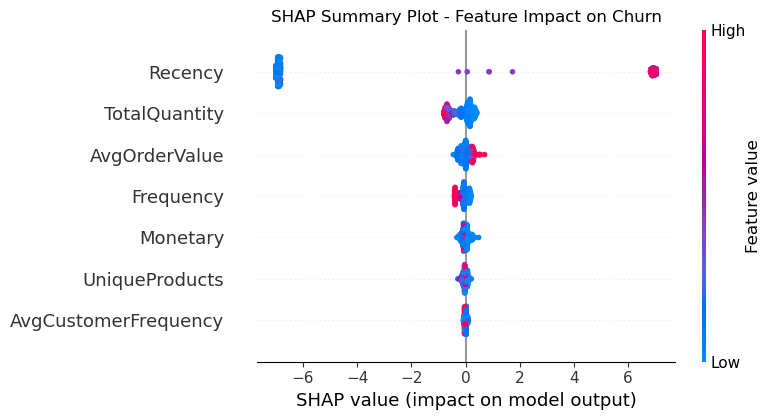

In [28]:
shap.summary_plot(shap_values, X_test, show=False)

plt.title("SHAP Summary Plot - Feature Impact on Churn")

plt.tight_layout()

plt.show()

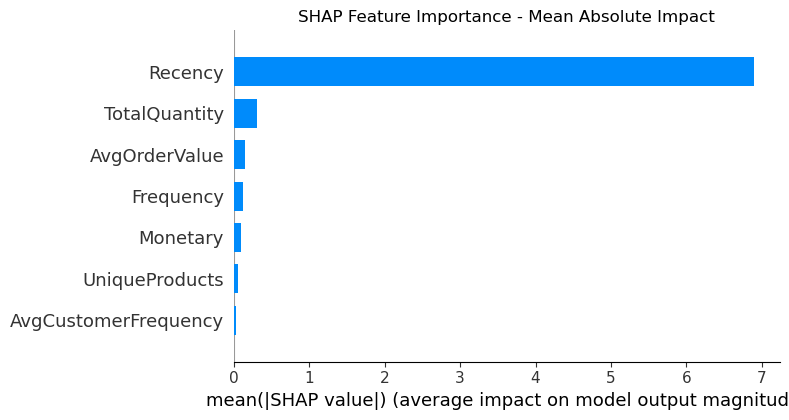

In [29]:
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)

plt.title("SHAP Feature Importance - Mean Absolute Impact")

plt.tight_layout()

plt.show()

## Step 12: SHAP Explanation for an Individual Customer

We look at one high-risk customer to see which features pushed their churn probability up.

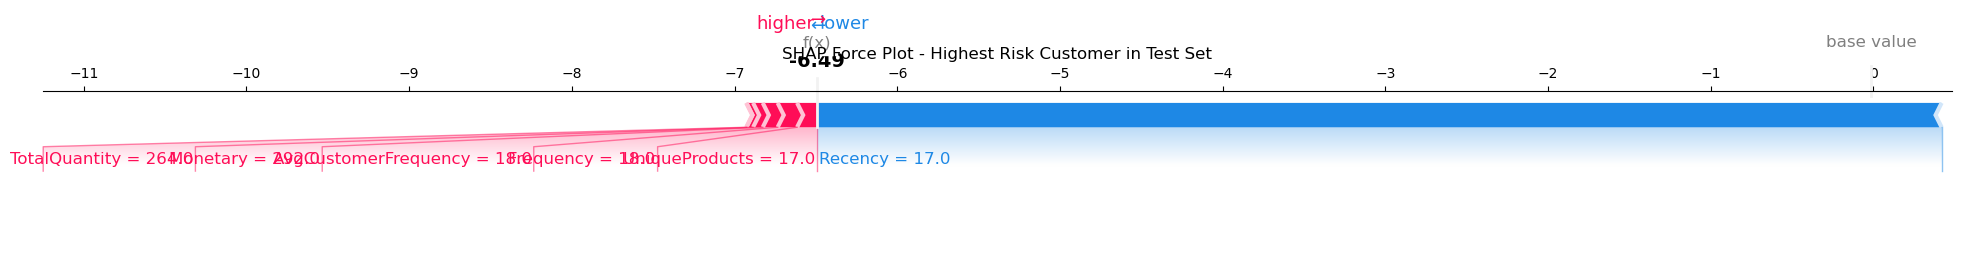

In [30]:
high_risk_idx = eval_df.index[0]

sample_idx = X_test.reset_index(drop=True).index[high_risk_idx]

shap.force_plot(
    explainer.expected_value,
    shap_values[sample_idx,:],
    X_test.iloc[sample_idx,:],
    matplotlib=True,
    show=False
)

plt.title("SHAP Force Plot - Highest Risk Customer in Test Set")

plt.tight_layout()

plt.show()

## Step 13: Save Predictions and Model

In [31]:
full_proba = model.predict_proba(X)[:,1]

churn_results = rfm.copy()

churn_results["ChurnProbability"] = full_proba

churn_results["PredictedChurn"] = (churn_results["ChurnProbability"] >= 0.5).astype(int)

churn_results.to_csv("../data/churn_predictions.csv", index=False)

print("Churn predictions saved")

churn_results.head()

Churn predictions saved


,Customer ID,Recency,Frequency,Monetary,Cluster,Segment,Churn,AvgOrderValue,UniqueProducts,TotalQuantity,AvgCustomerFrequency,ChurnProbability,PredictedChurn
0,12346.0,326,1,77183.60,1,VIP,1,77183.600000,1,74215,1.0,0.998759,1
1,12347.0,2,182,4310.00,0,Regular,0,23.681319,103,2458,182.0,0.000351,0
2,12348.0,75,31,1797.24,0,Regular,0,57.975484,22,2341,31.0,0.000552,0
3,12349.0,19,73,1757.55,0,Regular,0,24.076027,73,631,73.0,0.001358,0
4,12350.0,310,17,334.40,1,VIP,1,19.670588,17,197,17.0,0.999375,1


In [32]:
import os

os.makedirs("../models", exist_ok=True)

model.save_model("../models/xgb_churn_model.json")

print("XGBoost churn model saved")

XGBoost churn model saved


In [33]:
metrics_summary = pd.DataFrame({
    "Metric": ["AUC-ROC", "Precision@Top20%", "Churn Threshold (days)"],
    "Value": [auc, precision_top20, CHURN_THRESHOLD]
})

metrics_summary.to_csv("../data/churn_metrics.csv", index=False)

metrics_summary

,Metric,Value
0,AUC-ROC,1.0
1,Precision@Top20%,1.0
2,Churn Threshold (days),142.0


# Day 9 Findings

1. Explored the Recency distribution and chose a data-driven churn threshold (75th percentile).
2. Engineered additional behavioral features (AvgOrderValue, UniqueProducts, TotalQuantity, AvgCustomerFrequency) and merged them with RFM data.
3. Split data into train/test sets with stratification to preserve class balance.
4. Applied SMOTE to the training set only, balancing the churn classes.
5. Trained an XGBoost classifier and evaluated using AUC-ROC, classification report, confusion matrix, and ROC curve.
6. Computed Precision@Top20% to measure how well the model identifies the riskiest customers.
7. Used SHAP to explain global feature importance and individual high-risk customer predictions.
8. Saved churn predictions for all customers, evaluation metrics, and the trained model for use in later notebooks (inventory optimization, dashboard).